In [11]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

import shap
shap.initjs()

In [6]:
#load data 
data = pd.read_csv("data/abalone.csv")

In [8]:
data

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.1500,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.0700,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.2100,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.1550,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.0550,7
...,...,...,...,...,...,...,...,...,...
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10


In [7]:
len(data)

4177

Text(0.5, 0, 'Whole weight')

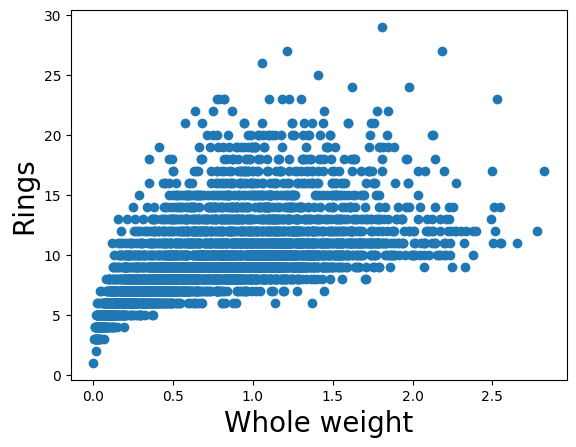

In [13]:
plt.scatter(data['Whole weight'], data['Rings'])
plt.ylabel('Rings', size = 20)
plt.xlabel('Whole weight', size=20)

Text(0.5, 0, 'Sex')

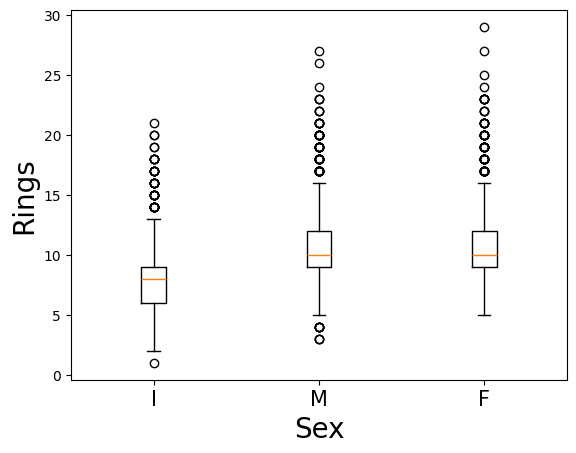

In [21]:
plt.boxplot(data[data.Sex=='I']['Rings'], positions=[1])
plt.boxplot(data[data.Sex=='M']['Rings'], positions=[2])
plt.boxplot(data[data.Sex=='F']['Rings'], positions=[3])

plt.xticks(ticks=[1,2,3], labels=['I', 'M', 'F'], size = 15)
plt.ylabel('Rings', size=20)
plt.xlabel('Sex', size=20)

<Axes: >

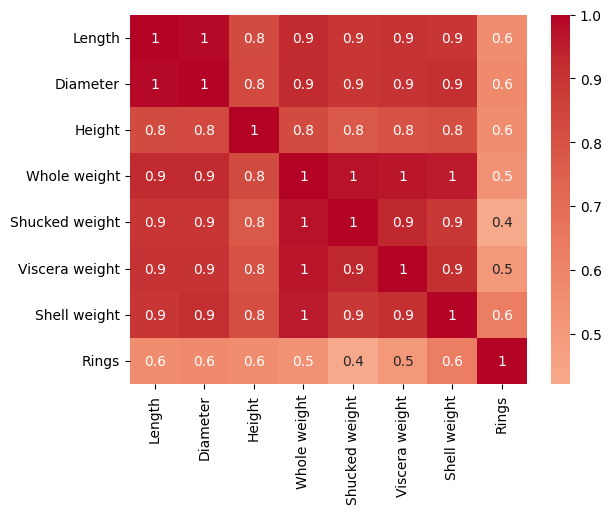

In [26]:
corr_matrix = data.drop(columns='Sex').corr()
corr_matrix
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=True, fmt='.1g')

In [33]:
y = data['Rings']
X = data[['Sex', 'Length', 'Height', 'Shucked weight', 'Viscera weight', 'Shell weight']]

In [34]:
#create dummy variable
X['Sex.M'] = [1 if s == 'M' else 0 for s in X['Sex']]
X['Sex.F'] = [1 if s == 'F' else 0 for s in X['Sex']]
X['Sex.I'] = [1 if s == 'I' else 0 for s in X['Sex']]

X = X.drop(columns='Sex')

/var/folders/3l/s_24n95s6cz9y4dpbqypg7jm0000gn/T/ipykernel_1958/3754979742.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex.M'] = [1 if s == 'M' else 0 for s in X['Sex']]
/var/folders/3l/s_24n95s6cz9y4dpbqypg7jm0000gn/T/ipykernel_1958/3754979742.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex.F'] = [1 if s == 'F' else 0 for s in X['Sex']]


In [35]:
X

,Length,Height,Shucked weight,Viscera weight,Shell weight,Sex.M,Sex.F,Sex.I
0,0.455,0.095,0.2245,0.1010,0.1500,1,0,0
1,0.350,0.090,0.0995,0.0485,0.0700,1,0,0
2,0.530,0.135,0.2565,0.1415,0.2100,0,1,0
3,0.440,0.125,0.2155,0.1140,0.1550,1,0,0
4,0.330,0.080,0.0895,0.0395,0.0550,0,0,1
...,...,...,...,...,...,...,...,...
4172,0.565,0.165,0.3700,0.2390,0.2490,0,1,0
4173,0.590,0.135,0.4390,0.2145,0.2605,1,0,0
4174,0.600,0.205,0.5255,0.2875,0.3080,1,0,0
4175,0.625,0.150,0.5310,0.2610,0.2960,0,1,0


In [36]:
y

0       15
1        7
2        9
3       10
4        7
        ..
4172    11
4173    10
4174     9
4175    10
4176    12
Name: Rings, Length: 4177, dtype: int64

In [43]:
#Train model
model = xgb.XGBRegressor(objective='reg:squarederror')
model.fit(X, y)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

Text(0.5, 0, 'Actual')

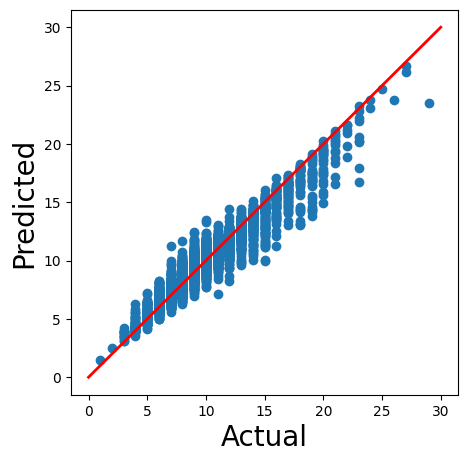

In [48]:
#get predictions
y_pred = model.predict(X)

plt.figure(figsize=(5,5))

plt.scatter(y, y_pred)
plt.plot([0,30], [0,30], color = 'r', linestyle = '-', linewidth=2)

plt.ylabel('Predicted', size=20)
plt.xlabel('Actual', size=20)

In [49]:
#Explainer
explainer = shap.Explainer(model)
shap_values = explainer(X)

In [50]:
np.shape(shap_values)

(4177, 8)